# Lesson 7: Finding Bridge Papers with Betweenness

**Duration:** ~10 minutes 
**Module:** 5 - GDS with Python 
**Dataset:** Cora Citation Network (continued)

## What You'll Learn

- What "bridge papers" are and why they matter
- How Betweenness Centrality identifies information bottlenecks
- How to compare PageRank (influence) with Betweenness (connectivity)
- How to interpret centrality scores in context

## Prerequisites

- Completion of Lesson 1 (data loaded, PageRank computed)
- Graph `cora-graph` should exist in memory


## Quick Setup Check

Verify you're connected and the graph exists from Lesson 1.


In [ ]:
import os
import pandas as pd
from IPython.display import display
from graphdatascience import GraphDataScience
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from pprint import pprint

# Load credentials from .env
load_dotenv()
uri = os.getenv('NEO4J_URI')
username = os.getenv('NEO4J_USERNAME')
password = os.getenv('NEO4J_PASSWORD')

# Connect to GDS
gds = GraphDataScience(uri, auth=(username, password))

# Get the graph object from Lesson 1
G = gds.graph.get("cora-graph")

print(f"Connected to GDS version: {gds.version()}")
print(f"Graph '{G.name()}' loaded: {G.node_count():,} nodes, {G.relationship_count():,} relationships")


Connected to GDS version: 2.25.0
Graph 'cora-graph' loaded: 2,708 nodes, 10,858 relationships


**Note:** If the graph doesn't exist, go back to Lesson 1 and run all cells first!


## Part 1: What is Betweenness Centrality?

**The concept:**
- Measures how often a node appears on shortest paths between other nodes
- Identifies **information brokers** and **bottlenecks**
- Different from PageRank (influence) – Betweenness measures **connectivity**

**Citation network interpretation:**
- High Betweenness = **bridge paper** connecting different research areas
- These papers may not be the most cited
- But they're essential for knowledge transfer across fields

**Real-world analogy:**
- PageRank: The famous professor everyone knows
- Betweenness: The colleague who connects you to researchers in other departments


### Business Value of Betweenness

**In fraud detection:**
- Find accounts that connect fraud rings (we saw this in Module 2)

**In supply chain:**
- Identify critical distribution hubs vulnerable to disruption

**In citation networks:**
- Discover interdisciplinary papers that bridge research areas


## Part 2: Computing Betweenness Centrality

Run Betweenness Centrality on the citation graph.


In [ ]:
# Run Betweenness Centrality and write results
bc_result = gds.betweenness.write(
 G,
 writeProperty='betweenness'
)

pprint(dict(bc_result))

{'centralityDistribution': {'max': 850663.9999999999,
                            'mean': 6053.358764900238,
                            'min': 0.0,
                            'p50': 941.6640615463257,
                            'p75': 4728.812499046326,
                            'p90': 12956.499999046326,
                            'p95': 23651.374999046326,
                            'p99': 72895.99999904633,
                            'p999': 324663.9999990463},
 'computeMillis': np.int64(180),
 'configuration': {'concurrency': 4,
                   'jobId': 'bb87f9e2-65bd-48c7-b3fa-652de878532d',
                   'logProgress': True,
                   'nodeLabels': ['*'],
                   'relationshipTypes': ['*'],
                   'sudo': False,
                   'writeConcurrency': 4,
                   'writeProperty': 'betweenness',
                   'writeToResultStore': False},
 'nodePropertiesWritten': np.int64(2708),
 'postProcessingMillis': np.int64(23),
 

**What just happened?**
- We computed Betweenness for every paper in the network
- The algorithm provides distribution statistics automatically
- High scores indicate papers on many shortest paths between others


## Part 3: Finding Bridge Papers

Query papers with highest Betweenness scores.


In [8]:
# Find top bridge papers
q_top_betweenness = """
MATCH (p:Paper)
WHERE p.betweenness IS NOT NULL
RETURN 
 p.paper_Id AS paperId,
 p.subject AS subject,
 p.betweenness AS betweenness,
 p.pageRank AS pageRank
ORDER BY p.betweenness DESC
LIMIT 10
"""

df_bridges = gds.run_cypher(q_top_betweenness)
print("Top 10 Bridge Papers:")
display(df_bridges)


Top 10 Bridge Papers:


,paperId,subject,betweenness,pageRank
0,35,Genetic_Algorithms,850663.008464,32.666616
1,3229,Neural_Networks,460317.981318,14.139130
2,4330,Probabilistic_Methods,324663.039514,8.420614
3,1365,Neural_Networks,310252.684689,16.556646
4,6213,Reinforcement_Learning,278922.368055,13.710552
5,887,Genetic_Algorithms,247254.155498,5.569773
6,1272,Theory,230426.323043,6.760252
7,910,Neural_Networks,193210.247870,9.970536
8,3231,Theory,182881.741410,7.331763
9,6214,Reinforcement_Learning,149405.321954,5.624984


**Interpretation:**
- Notice how PageRank and Betweenness highlight different papers
- High Betweenness papers act as connectors between research communities
- These are often methodological papers that apply to multiple domains


## Part 4: Comparing PageRank and Betweenness

Let's visualize the relationship between influence (PageRank) and connectivity (Betweenness).


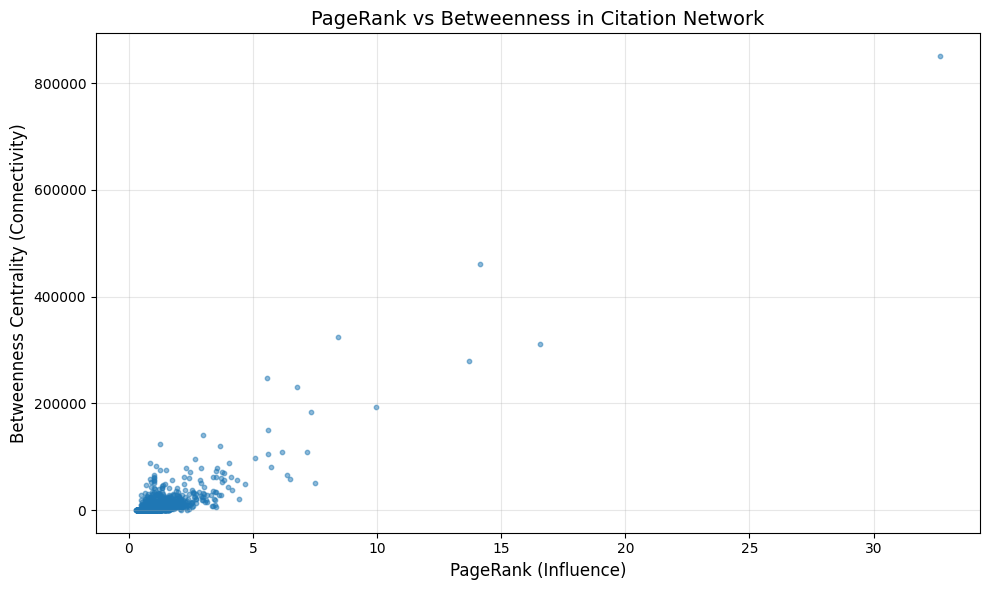

Total papers plotted: 2,708


In [9]:
# Get all papers with both metrics
q_both_metrics = """
MATCH (p:Paper)
WHERE p.pageRank IS NOT NULL AND p.betweenness IS NOT NULL
RETURN p.pageRank AS pageRank, 
 p.betweenness AS betweenness,
 p.subject AS subject
"""

df_metrics = gds.run_cypher(q_both_metrics)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_metrics['pageRank'], df_metrics['betweenness'], alpha=0.5, s=10)
plt.xlabel('PageRank (Influence)', fontsize=12)
plt.ylabel('Betweenness Centrality (Connectivity)', fontsize=12)
plt.title('PageRank vs Betweenness in Citation Network', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total papers plotted: {len(df_metrics):,}")


**What does this scatter plot tell us?**

- **Bottom-left cluster:** Most papers (low influence, low connectivity)
- **Top-right outliers:** "Superstar" papers (high influence AND high connectivity)
- **Top-left:** Bridge papers (high connectivity, moderate influence)
- **Bottom-right:** Influential but not connecting different areas

**Key insight:** Different algorithms reveal different types of importance!


## Part 5: Cross-Subject Bridge Analysis

Which subjects produce the most bridge papers?


In [11]:
# Analyze bridge papers by subject
from pprint import pp


q_subject_bridges = """
MATCH (p:Paper)
WHERE p.betweenness > 1000
RETURN 
 p.subject AS subject,
 count(p) AS num_bridge_papers,
 avg(p.betweenness) AS avg_betweenness,
 avg(p.pageRank) AS avg_pageRank
ORDER BY num_bridge_papers DESC
"""

df_subject_bridges = gds.run_cypher(q_subject_bridges)
print("Bridge Papers by Research Subject:")
pp(df_subject_bridges)


Bridge Papers by Research Subject:
                  subject  num_bridge_papers  avg_betweenness  avg_pageRank
0         Neural_Networks                401     11853.933131      1.238444
1                  Theory                206     12227.393490      1.370764
2   Probabilistic_Methods                205     13763.166810      1.312070
3      Genetic_Algorithms                188     14365.055452      1.449936
4              Case_Based                159      9406.839019      1.235695
5  Reinforcement_Learning                108     13187.700541      1.444575
6           Rule_Learning                 73      6838.471526      1.221616


**Business Insight:**

Subjects with many high-betweenness papers are **methodological fields** that influence multiple domains. In business:
- These are technologies/methods that enable cross-functional collaboration
- Investing in these areas has broader impact across the organization
- Teams working in these areas should be central to knowledge sharing


## Part 6: Finding Specific Cross-Subject Bridges

Let's find papers that specifically bridge different research areas.


In [13]:
# Find papers that cite across subjects AND have high betweenness
q_cross_subject = """
MATCH (p:Paper)-[:CITES]->(cited:Paper)
WHERE p.betweenness > 500
 AND p.subject <> cited.subject
WITH p, 
 collect(DISTINCT cited.subject) AS cited_subjects,
 count(DISTINCT cited.subject) AS num_subjects_cited
WHERE num_subjects_cited >= 3
RETURN 
 p.paper_Id AS paperId,
 p.subject AS subject,
 p.betweenness AS betweenness,
 p.pageRank AS pageRank,
 num_subjects_cited,
 cited_subjects
ORDER BY num_subjects_cited DESC, p.betweenness DESC
LIMIT 10
"""

df_cross_subject = gds.run_cypher(q_cross_subject)
print("Papers Bridging Multiple Research Areas:")
pp(df_cross_subject)


Papers Bridging Multiple Research Areas:
   paperId          subject   betweenness  pageRank  num_subjects_cited  \
0    28254  Neural_Networks   8692.063256  1.750932                   4   
1   299197  Neural_Networks  82818.084640  1.077071                   3   
2    35797  Neural_Networks  78153.955717  2.903276                   3   
3    46431  Neural_Networks  30302.985085  0.945920                   3   
4  1104449  Neural_Networks  18375.659704  0.806168                   3   
5    97892       Case_Based  17265.333527  0.830196                   3   
6    14549           Theory  10823.651809  1.298034                   3   
7  1103676  Neural_Networks   5063.263143  0.678185                   3   
8   323128           Theory   4609.897185  0.855220                   3   
9    68463    Rule_Learning   1672.777001  0.672921                   3   

                                      cited_subjects  
0  [Case_Based, Reinforcement_Learning, Theory, P...  
1  [Genetic_Algorithms,

**Why this matters:**

These papers are **truly interdisciplinary** – they:
1. Have high structural importance (Betweenness)
2. Actually cite work from 3+ different fields
3. Serve as knowledge transfer hubs

**In fraud detection:** These would be accounts connecting multiple fraud rings 
**In supply chain:** These would be critical distribution centers 
**In research:** These are the papers that synthesize knowledge across fields


## Part 7: Sampling for large graphs

For large graphs with millions of nodes, exact Betweenness computation can be slow. You can use sampling to get approximate results much faster.

The `samplingSize` parameter limits how many source nodes are used in the calculation.

In [14]:
# Run Betweenness with sampling for faster approximate results
bc_sampled_result = gds.betweenness.write(
    G,
    writeProperty='betweenness_sampled',
    samplingSize=500,
    samplingSeed=42
)

print(f"Computed sampled Betweenness for {bc_sampled_result['nodePropertiesWritten']:,} papers")
print(f"  Min score: {bc_sampled_result['centralityDistribution']['min']:.2f}")
print(f"  Max score: {bc_sampled_result['centralityDistribution']['max']:.2f}")
print(f"  Mean score: {bc_sampled_result['centralityDistribution']['mean']:.2f}")

Computed sampled Betweenness for 2,708 papers
  Min score: 0.00
  Max score: 135989.00
  Mean score: 1096.49


Let's compare the exact and sampled results to see how close the approximation is.

In [16]:
# Compare exact vs sampled results
q_compare = """
    MATCH (p:Paper)
    WHERE p.betweenness IS NOT NULL 
      AND p.betweenness_sampled IS NOT NULL
    RETURN p.paper_Id AS paperId,
           p.betweenness AS exact,
           p.betweenness_sampled AS sampled
    ORDER BY p.betweenness DESC
    LIMIT 10
"""

df_compare = gds.run_cypher(q_compare)
print("Top 10 papers: Exact vs Sampled Betweenness")
pp(df_compare)

Top 10 papers: Exact vs Sampled Betweenness
   paperId          exact        sampled
0       35  850663.008464  135988.810725
1     3229  460317.981318   84395.597724
2     4330  324663.039514   67198.302292
3     1365  310252.684689   69272.237180
4     6213  278922.368055   57619.050358
5      887  247254.155498   54440.292459
6     1272  230426.323043   35195.532450
7      910  193210.247870   34931.663605
8     3231  182881.741410   32799.257233
9     6214  149405.321954   29117.927577


**When to use sampling:**

- Your graph has millions of nodes
- Exact computation takes too long for your use case
- Approximate results are acceptable for your analysis

For the Cora dataset with 2,708 nodes, exact computation is fast enough that sampling isn't necessary. But on larger graphs, sampling can reduce computation time significantly while still identifying the most important bridge nodes.

## Summary: What You Accomplished

You've now mastered two fundamental centrality algorithms:

- Computed Betweenness Centrality to find bridge papers
- Compared PageRank (influence) with Betweenness (connectivity)
- Visualized the relationship between different centrality metrics
- Identified interdisciplinary papers connecting multiple fields
- Used pandas DataFrames and matplotlib for analysis

**Key insights:**
- **PageRank** identifies influential nodes (most cited papers)
- **Betweenness** identifies connectors (papers bridging research areas)
- Combining multiple algorithms reveals richer insights than any single metric

### Next Lesson

In Lesson 8, you'll use **Louvain** to detect research communities and prepare features for machine learning with **scaling** and embeddings.
